## Parse the ENA metadata & combien with basic manysearch info

In [1]:
import polars as pl
import matplotlib.pyplot as plt

In [2]:
pwd

'/group/datalabgrp/ctbrown/2026-pancoding-core/PRJEB88111.nanopore'

In [3]:
orig_df = (
    pl.scan_csv('PRJEB88111.x.mags+gtdb.manysearch.csv', ignore_errors=True)
    .with_columns(species_name=pl.col('query_name').str.split(' ').list.slice(1, 2).list.join( " "))
).collect()

In [4]:
orig_df.head(1)

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes,species_name
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str
"""GCA_038131005 s__Kariarchaeum …","""0a7585d443f2b72ce3ad24ee5f3c33…","""ERR15909855""",0.000529,1,21,1000,"""DNA""","""8fd570c89a8d877373d6f73b129184…",0.000015,0.000529,1.0,1.0,0.0,0.698179,0.590476,0.644328,0.698179,1,84774,"""s__Kariarchaeum pelagium"""


In [5]:
CORE_NAMES = [ x.strip() for x in open('../inputs.branchwater/names.list') ]
CORE_NAMES

['s__Bariatricus sp004560705',
 's__Colivicinus sp002299675',
 's__Cryptobacteroides sp000432655',
 's__Cryptobacteroides sp000434935',
 's__Cryptobacteroides sp034089285',
 's__Cryptobacteroides sp900546925',
 's__Fimisoma sp002320005',
 's__Floccifex porci',
 's__JAFBIX01 sp021531895',
 's__Lactobacillus amylovorus',
 's__Mogibacterium_A kristiansenii',
 's__Ornithospirochaeta sp022785155',
 's__Prevotella sp000434975',
 's__Prevotella sp002251295',
 's__Sodaliphilus sp004557565',
 's__UBA2868 sp004552595']

In [6]:
df = (orig_df
      .filter(pl.col('intersect_hashes') >= 20)
      .filter(pl.col('species_name').is_in(CORE_NAMES))
     )                                       

In [7]:
print(orig_df['match_name'].n_unique())
print(df['match_name'].n_unique())

108
59


In [8]:
by_acc = df.group_by('match_name').agg(
    n_core=pl.len(),
    med_intersect=pl.col('intersect_hashes').median(),
)
with pl.Config(tbl_rows=-1):
    print(by_acc.sort('n_core'))

shape: (59, 3)
┌─────────────┬────────┬───────────────┐
│ match_name  ┆ n_core ┆ med_intersect │
│ ---         ┆ ---    ┆ ---           │
│ str         ┆ u32    ┆ f64           │
╞═════════════╪════════╪═══════════════╡
│ ERR15909890 ┆ 6      ┆ 46.0          │
│ ERR15909878 ┆ 7      ┆ 64.0          │
│ ERR15909869 ┆ 8      ┆ 70.5          │
│ ERR15909856 ┆ 8      ┆ 55.0          │
│ ERR15909853 ┆ 8      ┆ 54.0          │
│ ERR15909872 ┆ 8      ┆ 49.0          │
│ ERR15909855 ┆ 8      ┆ 31.5          │
│ ERR15909877 ┆ 9      ┆ 76.0          │
│ ERR15909859 ┆ 9      ┆ 50.0          │
│ ERR15909887 ┆ 9      ┆ 61.0          │
│ ERR15909889 ┆ 9      ┆ 46.0          │
│ ERR15909888 ┆ 9      ┆ 60.0          │
│ ERR15909852 ┆ 9      ┆ 97.0          │
│ ERR15909892 ┆ 10     ┆ 33.5          │
│ ERR15909874 ┆ 10     ┆ 63.5          │
│ ERR15909882 ┆ 10     ┆ 88.0          │
│ ERR15909879 ┆ 10     ┆ 63.5          │
│ ERR15909885 ┆ 10     ┆ 41.0          │
│ ERR15909858 ┆ 11     ┆ 52.0          │
│

In [9]:
ls *.mf.csv

PRJEB88111.mf.csv


In [10]:
mf_df = pl.read_csv('PRJEB88111.mf.csv', skip_lines=1)

In [11]:
mf_df.sort('n_hashes')

internal_location,md5,md5short,ksize,moltype,num,scaled,n_hashes,with_abundance,name,filename
str,str,str,i64,str,i64,i64,i64,bool,str,str
"""ERR15942208.sig.zip""","""62407e8ebcb8d9d7a6d036a28fefba…","""62407e8e""",21,"""DNA""",0,1000,61708,true,"""ERR15942208""","""ERR15942208.fastq.gz"""
"""ERR15942153.sig.zip""","""09fd735720c2a9b9e980522fabda91…","""09fd7357""",21,"""DNA""",0,1000,62007,true,"""ERR15942153""","""ERR15942153.fastq.gz"""
"""ERR15909855.sig.zip""","""8fd570c89a8d877373d6f73b129184…","""8fd570c8""",21,"""DNA""",0,1000,63791,true,"""ERR15909855""","""ERR15909855.fastq.gz"""
"""ERR15942144.sig.zip""","""f7260587ba6e88bc3caa5d3d7c84f1…","""f7260587""",21,"""DNA""",0,1000,65416,true,"""ERR15942144""","""ERR15942144.fastq.gz"""
"""ERR15909855.sig.zip""","""87daeb90611b8997d6eebc148fdcfc…","""87daeb90""",31,"""DNA""",0,1000,65550,true,"""ERR15909855""","""ERR15909855.fastq.gz"""
…,…,…,…,…,…,…,…,…,…,…
"""ERR15936522.sig.zip""","""c87df86bc0087ddd9016d872cf5e7f…","""c87df86b""",51,"""DNA""",0,1000,9878542,true,"""ERR15936522""","""ERR15936522.fastq.gz"""
"""ERR15935141.sig.zip""","""fb1cedca9624b75323d33bbc4a4a89…","""fb1cedca""",51,"""DNA""",0,1000,10307669,true,"""ERR15935141""","""ERR15935141.fastq.gz"""
"""ERR15934513.sig.zip""","""b026598c7178a3d89a1db2ebc8ae41…","""b026598c""",51,"""DNA""",0,1000,11162227,true,"""ERR15934513""","""ERR15934513.fastq.gz"""


In [12]:
join_df = (
    by_acc
    .join(mf_df, left_on='match_name', right_on='name', how='inner')
    .select(['match_name', 'n_core', 'n_hashes', 'med_intersect']) 
)
with pl.Config(tbl_rows=-1):
    print(join_df.sort('n_hashes'))

shape: (177, 4)
┌─────────────┬────────┬──────────┬───────────────┐
│ match_name  ┆ n_core ┆ n_hashes ┆ med_intersect │
│ ---         ┆ ---    ┆ ---      ┆ ---           │
│ str         ┆ u32    ┆ i64      ┆ f64           │
╞═════════════╪════════╪══════════╪═══════════════╡
│ ERR15909855 ┆ 8      ┆ 63791    ┆ 31.5          │
│ ERR15909855 ┆ 8      ┆ 65550    ┆ 31.5          │
│ ERR15909855 ┆ 8      ┆ 67653    ┆ 31.5          │
│ ERR15909890 ┆ 6      ┆ 74127    ┆ 46.0          │
│ ERR15909890 ┆ 6      ┆ 76655    ┆ 46.0          │
│ ERR15909888 ┆ 9      ┆ 80173    ┆ 60.0          │
│ ERR15909890 ┆ 6      ┆ 80687    ┆ 46.0          │
│ ERR15909888 ┆ 9      ┆ 82205    ┆ 60.0          │
│ ERR15909878 ┆ 7      ┆ 82496    ┆ 64.0          │
│ ERR15909853 ┆ 8      ┆ 83559    ┆ 54.0          │
│ ERR15909858 ┆ 11     ┆ 83948    ┆ 52.0          │
│ ERR15909878 ┆ 7      ┆ 84293    ┆ 64.0          │
│ ERR15909888 ┆ 9      ┆ 85657    ┆ 60.0          │
│ ERR15909853 ┆ 8      ┆ 85907    ┆ 54.0        

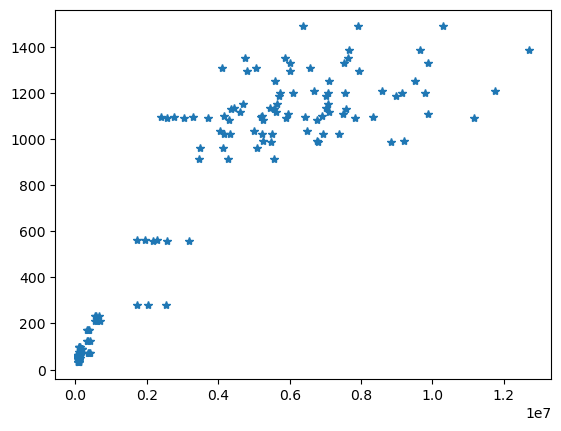

In [13]:
plt.plot(join_df['n_hashes'], join_df['med_intersect'], '*')

In [16]:
with pl.Config(tbl_rows=-1):
    print(df.filter(pl.col('match_name') == 'ERR15934787'))


shape: (16, 21)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ query_nam ┆ query_md5 ┆ match_nam ┆ containme ┆ … ┆ max_conta ┆ n_weighte ┆ total_wei ┆ species_ │
│ e         ┆ ---       ┆ e         ┆ nt        ┆   ┆ inment_an ┆ d_found   ┆ ghted_has ┆ name     │
│ ---       ┆ str       ┆ ---       ┆ ---       ┆   ┆ i         ┆ ---       ┆ hes       ┆ ---      │
│ str       ┆           ┆ str       ┆ f64       ┆   ┆ ---       ┆ i64       ┆ ---       ┆ str      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆ i64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ GCA_02872 ┆ 5f3ec5317 ┆ ERR159347 ┆ 0.169775  ┆ … ┆ 0.919025  ┆ 8096      ┆ 9708467   ┆ s__Prevo │
│ 7695 s__P ┆ 3d835a3cb ┆ 87        ┆           ┆   ┆           ┆           ┆           ┆ tella    │
│ revotella ┆ 129557502 ┆           ┆           ┆   ┆           ┆          